In [ ]:
# Define source path for journal results
SOURCE_PATH = "../../save_and_results/old/journal/"

In [27]:
import sys
sys.path.append('..')

import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
import matplotlib.pyplot as plt

from utils.display_tools import load_best_forecasts,  display_predictions_2


In [28]:
lot = pickle.load(open("../../save_and_results/cache_lot.p", "rb"))
data = pickle.load(open("../../save_and_results/cache_endog.p", "rb"))
exogs = pickle.load(open("../../save_and_results/cache_exogs.p", "rb"))

In [29]:
loc = "Moehne"
direction = "lot"
d = lot[loc][direction]
y_ = d.loc[d.index.year == 2020]

In [31]:
ms = {}
fc = {}
mae = {}

for x in [str(n) for n in range(0,4)]:
    model_spec, forecasts = load_best_forecasts(SOURCE_PATH  + x, direction="lot")
    if (x == "1")  or (x == "2"):
        forecasts.drop(columns="sarimax", inplace=True)
    score = pd.DataFrame(
        (np.abs(forecasts - y_.values).mean().values),
        index=forecasts.columns,
        columns=["MAE"],
    )
    ms[x] = model_spec
    fc[x] = forecasts
    fc[x].columns = [x  if x != "sar" else "ari" for x in fc[x].columns.str[:3]]
    mae[x] = score
    mae[x].index = [x  if x != "sar" else "ari" for x in mae[x].index.str[:3]]


chronos = pd.read_csv(SOURCE_PATH + "chronos/Moehne_lot_chronos_zero_shot_chronos.csv", index_col=0)
tfm = pd.read_csv(SOURCE_PATH + "tfm/Moehne_lot_tfm_zero_shot_chronos.csv", index_col=0)
# append foundational models
fc["3"]["chr"] = chronos.values[:-1]
fc["3"]["tfm"] = tfm.values[:-1]

mae["3"] = mae["3"].T

mae["3"]["chr"] = np.abs(y_ - chronos.values[:-1]).mean().values[0]
mae["3"]["tfm"] = np.abs(y_ - tfm.values[:-1]).mean().values[0]

mae["3"] = mae["3"].T

mae["3"].index = [x  if x != "sar" else "ari" for x in mae["3"].index.str[:3]]

/tmp/ipykernel_92549/96337504.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=3)


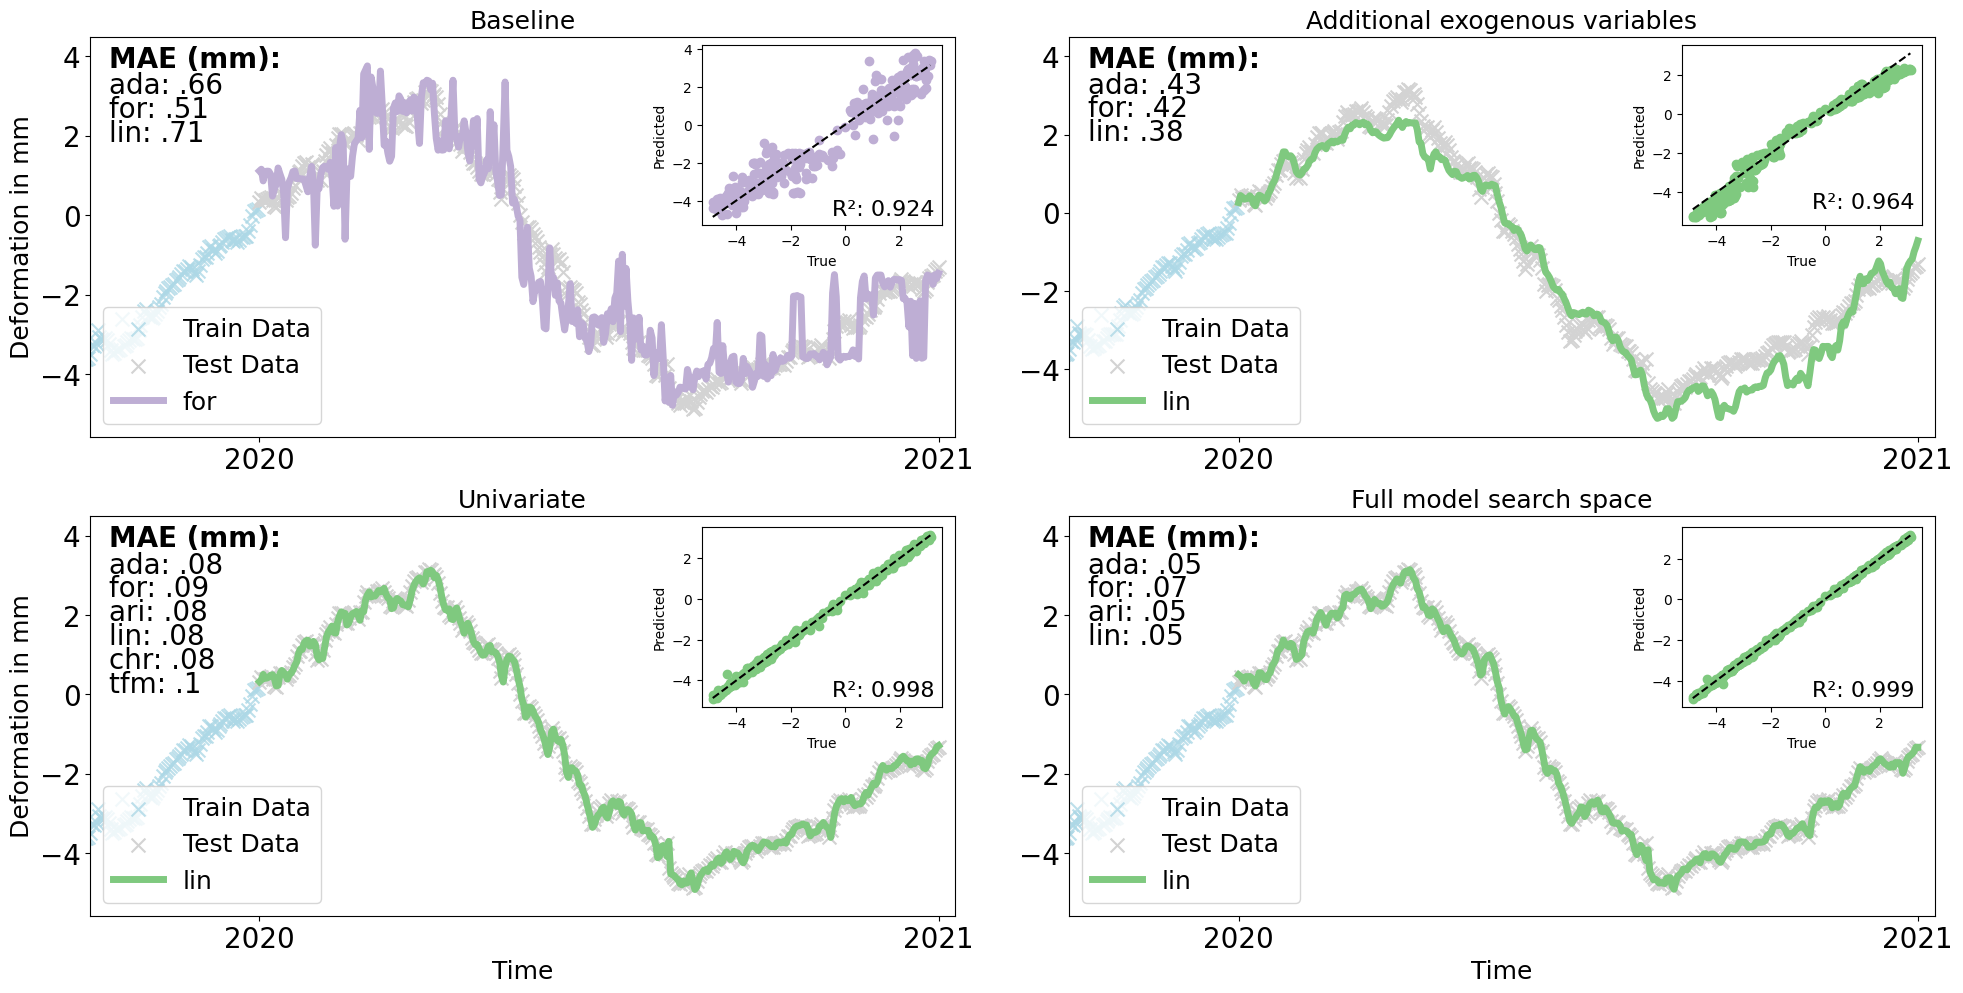

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

cm_subsection = linspace(0, 1, 7)
colors_add = iter([cm.Accent(x) for x in cm_subsection])

colors_add = list(colors_add)

colors = {


"ari":colors_add[3],
"for": colors_add[1],
"ada": colors_add[2],
"lin": colors_add[0],
"var": colors_add[4],
"chr": colors_add[5],
"tfm": colors_add[6]
}

display_predictions_2(fig,axs[0,0],d,fc["1"],y_, mae["1"],colors=colors,y_lim=[],rs_fontsize=16,rs_position=[-0.5, -4.8],x_lim=[1640,2105], alphas = [0.0,1.0], loc_2=[0.352, 0.77, 0.12, 0.18], marker="x", error_coords=[10, 7, 13], r_2_round=3)
display_predictions_2(fig,axs[0,1],d,fc["2"],y_, mae["2"],colors=colors,y_lim=[],rs_fontsize=16,rs_position=[-0.5, -4.8], x_lim=[1640,2105], alphas = [0.0,1.0], loc_2=[0.842, 0.77, 0.12, 0.18], marker="x", error_coords=[10, 7, 13], r_2_round=3)
display_predictions_2(fig,axs[1,0],d,fc["3"],y_, mae["3"],colors=colors,y_lim=[],rs_fontsize=16,rs_position=[-0.5, -4.8], x_lim=[1640,2105], alphas = [0.0,1.0], loc_2=[0.352, 0.288, 0.12, 0.18], marker="x", error_coords=[10, 7, 13], r_2_round=3)
display_predictions_2(fig,axs[1,1],d,fc["0"],y_, mae["0"],colors=colors,y_lim=[],rs_fontsize=16,rs_position=[-0.5, -4.8], x_lim=[1640,2105], alphas = [0.0,1.0], loc_2=[0.842, 0.288, 0.12, 0.18], marker="x", error_coords=[10, 7, 13], r_2_round=3)

#fig.suptitle("Dammverformung (" + "Radial" + ")", fontsize=20)

fig.tight_layout(pad=3)
axs[1,0].set_ylabel("Deformation in mm", fontsize=18)
axs[0,0].set_ylabel("Deformation in mm", fontsize=18)

axs[1,0].set_xlabel("Time", fontsize=18)
axs[1,1].set_xlabel("Time", fontsize=18)

axs[0,0].set_title("Baseline", fontsize=18)
axs[0,1].set_title("Additional exogenous variables", fontsize=18)
axs[1,0].set_title("Univariate", fontsize=18)
axs[1,1].set_title("Full model search space", fontsize=18)


axs[0,0].legend(loc=3, fontsize=18)
axs[0,1].legend(loc=3, fontsize=18)
axs[1,0].legend(loc=3, fontsize=18)
axs[1,1].legend(loc=3, fontsize=18)


plt.savefig("../../imgs/mdpi_1.pdf",)